In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_excel("BlinkIT Grocery Data.xlsx")

In [5]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                8523 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


,Outlet Establishment Year,Item Visibility,Item Weight,Sales,Rating
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,2016.450546,0.066132,12.857645,140.992783,3.965857
std,3.189396,0.051598,4.226124,62.275067,0.605651
min,2011.000000,0.000000,4.555000,31.290000,1.000000
25%,2014.000000,0.026989,9.310000,93.826500,4.000000
50%,2016.000000,0.053931,12.857645,143.012800,4.000000
75%,2018.000000,0.094585,16.000000,185.643700,4.200000
max,2022.000000,0.328391,21.350000,266.888400,5.000000


In [30]:
total_sales = df["Sales"].sum()
print("Total Sales: ", round(total_sales,2))

Total Sales:  1201681.49


In [29]:
average_sales = df["Sales"].mean()
print("Average sales: ", round(average_sales,2))

Average sales:  140.99


In [28]:
average_rating = df["Rating"].mean()
print("Average Rating: ", round(average_rating,2))

Average Rating:  3.97


In [24]:
total_products = df["Item Identifier"].nunique()
print("Total Products: ", total_products)

Total Products:  1559


In [25]:
total_outlets = df["Outlet Identifier"].nunique()
print("Total Outlet: ", total_outlets)

Total Outlet:  10


In [41]:
#Sales by ItemType
sales_by_item = df.groupby("Item Type")["Sales"].sum().sort_values(ascending=False)
sales_by_item


Item Type
Fruits and Vegetables    178124.0810
Snack Foods              175433.9224
Household                135976.5254
Frozen Foods             118558.8814
Dairy                    101276.4616
Canned                    90706.7290
Baking Goods              81894.7364
Health and Hygiene        68025.8388
Meat                      59449.8638
Soft Drinks               58514.1670
Breads                    35379.1198
Hard Drinks               29334.6806
Others                    22451.8916
Starchy Foods             21880.0274
Breakfast                 15596.6966
Seafood                    9077.8700
Name: Sales, dtype: float64

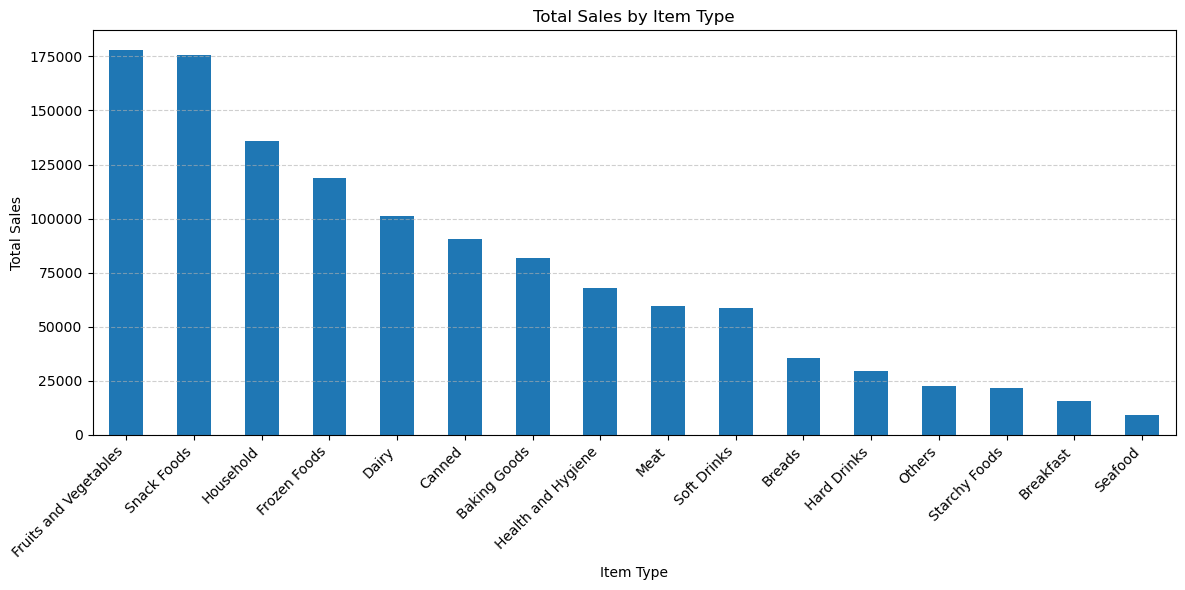

In [43]:
plt.figure(figsize=(12,6))

sales_by_item.plot(kind = "bar")

plt.title("Total Sales by Item Type")
plt.xlabel("Item Type")
plt.ylabel("Total Sales")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()

plt.show()

In [44]:
#Sales by Outlet Type

sales_by_outlet = df.groupby("Outlet Type")["Sales"].sum().sort_values(ascending = False)
sales_by_outlet

Outlet Type
Supermarket Type1    787549.8928
Grocery Store        151939.1490
Supermarket Type2    131477.7764
Supermarket Type3    130714.6746
Name: Sales, dtype: float64

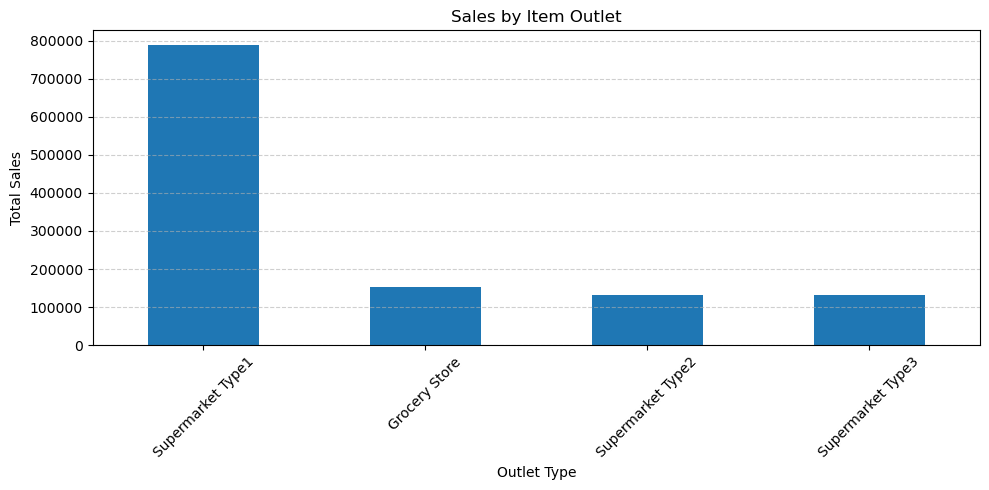

In [57]:
plt.figure(figsize=(10,5))

sales_by_outlet.plot(kind="bar")

plt.title("Sales by Item Outlet")
plt.xlabel("Outlet Type")
plt.ylabel("Total Sales")

plt.xticks(rotation = 45)
plt.grid(axis = "y", linestyle = "--", alpha = 0.6)
plt.tight_layout()

plt.show()

In [2]:
#Sales by Outlet Size
sales_by_outlet_size = df.groupby("Outlet Size")["Sales"].sum().sort_values(ascending=False)
sales_by_outlet_size

NameError: name 'df' is not defined

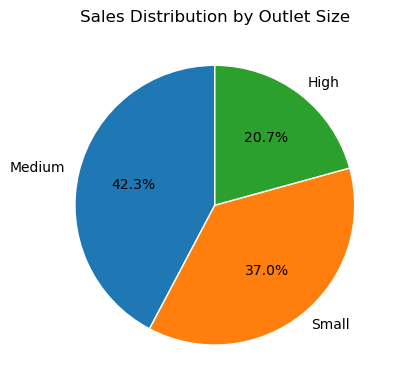

In [60]:
plt.figure(figsize = (8,4))

plt.pie(
    sales_by_outlet_size,
    labels=sales_by_outlet_size.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor":"white"}
)

plt.title("Sales Distribution by Outlet Size")
plt.tight_layout()

plt.show()

In [61]:
#Sales by Fat
sales_by_fat = df.groupby("Item Fat Content")["Sales"].sum().sort_values(ascending=False)
sales_by_fat

Item Fat Content
Low Fat    776319.6884
Regular    425361.8044
Name: Sales, dtype: float64

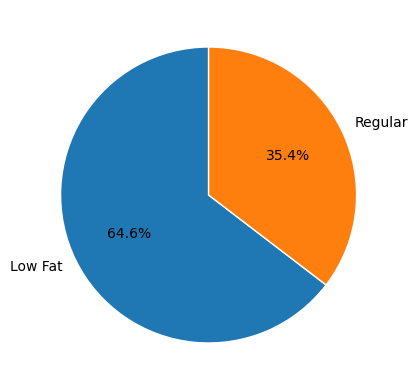

In [64]:
plt.figure(figsize=(8,4))

plt.pie (
    sales_by_fat, 
    labels=sales_by_fat.index,
    autopct="%1.1f%%",
    startangle = 90,
    wedgeprops = {"edgecolor": "White"}
)

plt.title("Sales Distribution by Outlet Type ")
plt.tight_layout()

plt.show()

In [66]:
#Sales by Location
sales_by_location = df.groupby("Outlet Location Type")["Sales"].sum().sort_values(ascending=False)
sales_by_location

Outlet Location Type
Tier 3    472133.0332
Tier 2    393150.6476
Tier 1    336397.8120
Name: Sales, dtype: float64

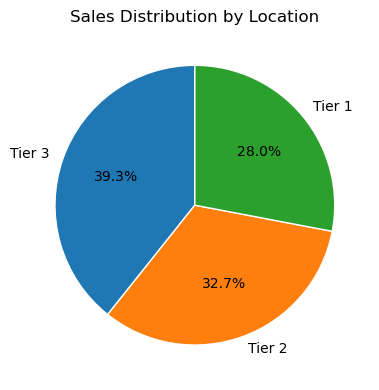

In [74]:
plt.figure(figsize = (8,4))

plt.pie (
    sales_by_location, 
    labels=sales_by_location.index,
    autopct="%1.1f%%",
    startangle = 90,
    wedgeprops = {"edgecolor": "White"}
)

plt.title("Sales Distribution by Location")
plt.tight_layout()

plt.show()


In [75]:
#Sales by Year
sales_by_year = (
    df.groupby("Outlet Establishment Year")["Sales"]
      .sum()
      .sort_index()
)

sales_by_year

Outlet Establishment Year
2011     78131.5666
2012    130476.8598
2014    131809.0156
2015    130942.7802
2016    132113.3698
2017    133103.9070
2018    204522.2570
2020    129103.9604
2022    131477.7764
Name: Sales, dtype: float64

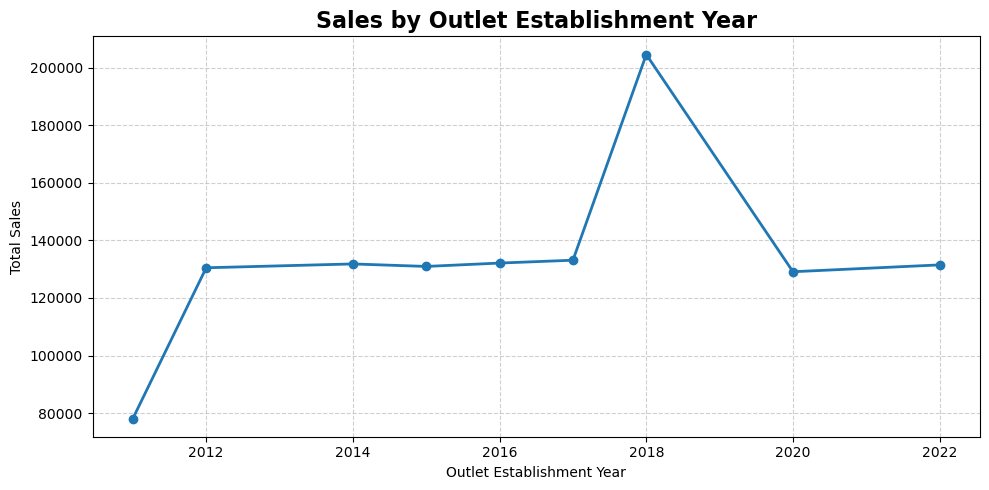

In [78]:
plt.figure(figsize=(10,5))

plt.plot(
    sales_by_year.index,
    sales_by_year.values,
    marker="o",
    linewidth=2
)

plt.title("Sales by Outlet Establishment Year", fontsize=16, fontweight="bold")
plt.xlabel("Outlet Establishment Year")
plt.ylabel("Total Sales")

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()

plt.show()

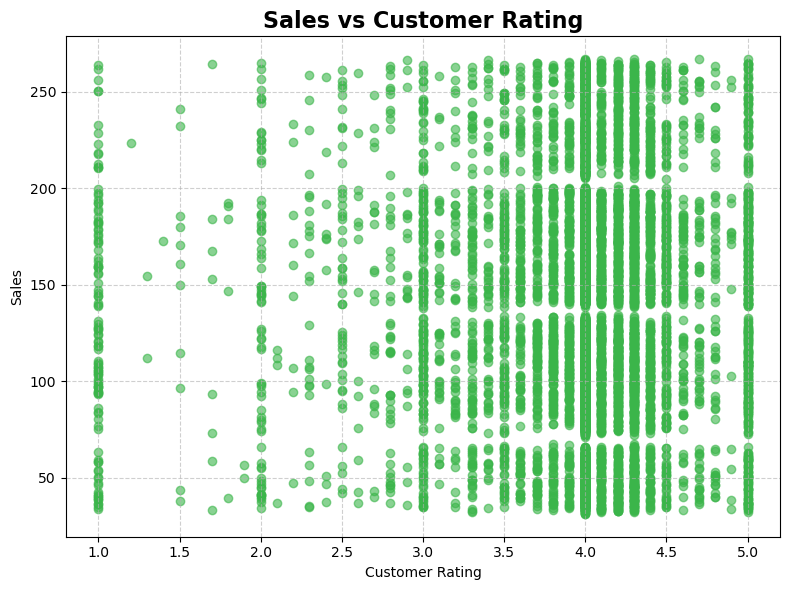

In [79]:
#Relationship Between Sales and Rating (Scatter Plot)
plt.figure(figsize=(8,6))

plt.scatter(
    df["Rating"],
    df["Sales"],
    alpha=0.6,
    color="#3BB54A"
)

plt.title("Sales vs Customer Rating", fontsize=16, fontweight="bold")
plt.xlabel("Customer Rating")
plt.ylabel("Sales")

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()

plt.show()

In [80]:
#Correlation Analysis (Heatmap)
numeric_df = df.select_dtypes(include=["int64", "float64"])
numeric_df.head()

,Outlet Establishment Year,Item Visibility,Item Weight,Sales,Rating
0,2012,0.100014,15.10,145.4786,5.0
1,2022,0.008596,11.80,115.3492,5.0
2,2016,0.025896,13.85,165.0210,5.0
3,2014,0.042278,12.15,126.5046,5.0
4,2015,0.033970,19.60,55.1614,5.0


In [81]:
correlation = numeric_df.corr()
correlation

,Outlet Establishment Year,Item Visibility,Item Weight,Sales,Rating
Outlet Establishment Year,1.000000,-0.058087,-0.004475,-0.000654,0.000414
Item Visibility,-0.058087,1.000000,-0.012048,-0.001315,0.000798
Item Weight,-0.004475,-0.012048,1.000000,0.024756,0.002487
Sales,-0.000654,-0.001315,0.024756,1.000000,0.011329
Rating,0.000414,0.000798,0.002487,0.011329,1.000000


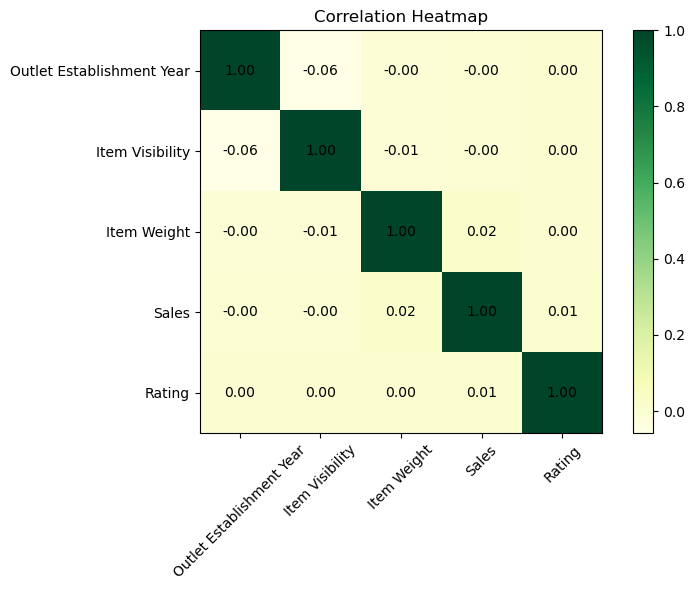

In [82]:
plt.figure(figsize=(8,6))

plt.imshow(correlation, cmap="YlGn", interpolation="nearest")

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(j, i,
                 f"{correlation.iloc[i,j]:.2f}",
                 ha="center",
                 va="center",
                 color="black")

plt.tight_layout()

plt.show()

In [6]:
df.to_excel("blinkit_cleaned.xlsx", index=False)